# 08. Experiencia externa

**Fuente:** `data/raw/experenciaexterna.csv`  
**Salida:** `data/processed/experiencia_externa.csv`

Historial laboral del personal fuera de ESPOL (cargo, institucion, fechas, tipo de relacion laboral). Los codigos CATEXPERIENCIA y ROLACADEMICOEXPERIENCIA se decodifican usando data/raw/diccionarioexperienciaexterna.txt.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [2]:
df = pc.leer_csv('experenciaexterna.csv', low_memory=False)
df.head()

Leido experenciaexterna.csv con encoding=utf-8-sig -> 13818 filas, 21 columnas


,IDHISTORIALABORAL,IDPERSONA,CARGO,INSTITUCION,TIPOINSTITUCION,RELACIONLABORAL,FECHADESDE,FECHAHASTA,PAIS,IDPAIS,TIEMPODEDICACION,REFEVIDENCIA,REFEVALUACIONES,CATEXPERIENCIA,CATEGORIAEXPERIENCIADESCRIPCION,ROLACADEMICO,ROLACADEMICOEXPERIENCIA,VIGENTE,TIPOPONENCIA,NOMBRECONGRESO,MODALIDAD
0,8732,660654,AYUDANTE DE INVESTIGACIÓN,ESCUELA POLITÉCNICA NACIONAL,PÚBLICA,CONTRATO CON RELACIÓN DE DEPENDENCIA,2018-07-02,2019-08-31,ECUADOR,1,MEDIO TIEMPO,"456599,459052",NaN,PC,POR CLASIFICAR,NaN,NaN,0,NaN,NaN,NaN
1,87,1614,INGENIERA DE MANTENIMIENTO,FABRICACIONES ELECTROMECÁNICAS FETL S.A.,PRIVADA,CONTRATO SIN RELACIÓN DE DEPENDENCIA,1996-01-02,2000-11-30,ECUADOR,1,MEDIO TIEMPO,NaN,NaN,PC,POR CLASIFICAR,NaN,NaN,0,NaN,NaN,NaN
2,11151,669877,ingeniero civil,celec,PÚBLICA,CONTRATO SIN RELACIÓN DE DEPENDENCIA,2018-08-03,2018-12-11,ECUADOR,1,MEDIO TIEMPO,"1012396,956161",NaN,PC,POR CLASIFICAR,NaN,NaN,0,NaN,NaN,NaN
3,295,1373,DOCENTE,UNIV. POLITECNICA SALESIANA,PRIVADA,CONTRATO CON RELACIÓN DE DEPENDENCIA,2008-06-01,2010-09-30,ECUADOR,1,MEDIO TIEMPO,"115174,114051",NaN,PC,POR CLASIFICAR,NaN,NaN,0,NaN,NaN,NaN
4,2903,1108,NaN,UNIVERSIDAD POLITÉCNICA SALESIANA,NaN,NaN,2015-12-14,NaN,ECUADOR,1,MEDIO TIEMPO,"51882,50863","51883,50864",PC,POR CLASIFICAR,NaN,NaN,0,NaN,NaN,NaN


## 2. Exploración inicial

In [3]:
pc.resumen(df, 'experiencia_externa')

--- Resumen experiencia_externa ---
Dimensiones: 13818 filas x 21 columnas
Filas duplicadas: 0
Columnas con nulos (%):
MODALIDAD                  100.0
TIPOPONENCIA               100.0
NOMBRECONGRESO             100.0
REFEVALUACIONES             98.3
ROLACADEMICOEXPERIENCIA     90.9
ROLACADEMICO                90.9
REFEVIDENCIA                26.1
RELACIONLABORAL             20.6
CARGO                        9.4
FECHAHASTA                   8.8
TIPOINSTITUCION              4.7
INSTITUCION                  0.2
FECHADESDE                   0.1
dtype: float64


In [4]:
df.dtypes

IDHISTORIALABORAL                    int64
IDPERSONA                            int64
CARGO                                  str
INSTITUCION                            str
TIPOINSTITUCION                        str
RELACIONLABORAL                        str
FECHADESDE                             str
FECHAHASTA                             str
PAIS                                   str
IDPAIS                               int64
TIEMPODEDICACION                       str
REFEVIDENCIA                           str
REFEVALUACIONES                        str
CATEXPERIENCIA                         str
CATEGORIAEXPERIENCIADESCRIPCION        str
ROLACADEMICO                           str
ROLACADEMICOEXPERIENCIA                str
VIGENTE                              int64
TIPOPONENCIA                       float64
NOMBRECONGRESO                     float64
MODALIDAD                          float64
dtype: object

## 3. Limpieza

In [5]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.99)
df = pc.quitar_columnas_constantes(df)

Columnas eliminadas por tener >= 99% de nulos: ['TIPOPONENCIA', 'NOMBRECONGRESO', 'MODALIDAD']


## 5. Tipado de fechas e identificadores

In [6]:
df = pc.castear_fechas(df, ['FECHADESDE', 'FECHAHASTA'])
df = pc.castear_enteros(df, ['IDHISTORIALABORAL', 'IDPERSONA', 'IDPAIS'])

## 6. Decodificación de catálogos

Códigos definidos en `data/raw/diccionarioexperienciaexterna.txt`: CATEXPERIENCIA (PC=Por clasificar, AD=Administrativa, AC=Académica) y ROLACADEMICO (PR=Profesor, FA=Facilitador, PA=Personal de apoyo, AY=Ayudante). ROLACADEMICOEXPERIENCIA ya viene con el texto completo en el CSV de origen.

In [7]:
df = pc.decodificar_experiencia_externa(df)
df[['CATEXPERIENCIA', 'CATEXPERIENCIA_DESC', 'ROLACADEMICO', 'ROLACADEMICO_DESC', 'ROLACADEMICOEXPERIENCIA']].drop_duplicates().head(10)

,CATEXPERIENCIA,CATEXPERIENCIA_DESC,ROLACADEMICO,ROLACADEMICO_DESC,ROLACADEMICOEXPERIENCIA
0,PC,POR CLASIFICAR,<NA>,NaN,<NA>
6,AD,ADMINISTRATIVA,<NA>,NaN,<NA>
39,AC,ACADEMICA,PR,PROFESOR,PROFESOR
123,AC,ACADEMICA,<NA>,NaN,<NA>
360,AC,ACADEMICA,PA,PERSONAL DE APOYO,PERSONAL DE APOYO
390,AD,ADMINISTRATIVA,PA,PERSONAL DE APOYO,PERSONAL DE APOYO
542,AC,ACADEMICA,AY,AYUDANTE,AYUDANTE
815,AC,ACADEMICA,FA,FACILITADOR,FACILITADOR
2693,AD,ADMINISTRATIVA,PR,PROFESOR,PROFESOR


## Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Categoría de la experiencia externa** (académica, administrativa, por clasificar).

<Axes: title={'center': 'Experiencia externa por categoría'}, xlabel='CATEXPERIENCIA_DESC'>

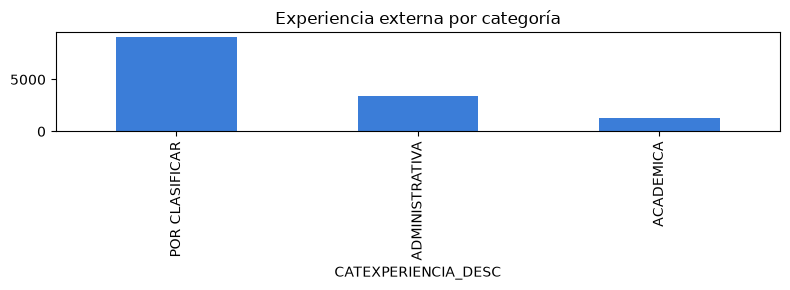

In [9]:
pc.grafico_barras(df['CATEXPERIENCIA_DESC'], 'Experiencia externa por categoría', horizontal=False)

**Rol académico** declarado en la experiencia externa (solo ~9% de los registros lo especifica).

<Axes: title={'center': 'Experiencia externa por rol académico'}, xlabel='ROLACADEMICO_DESC'>

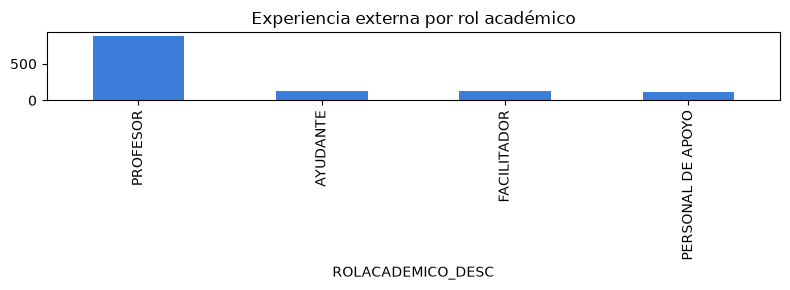

In [10]:
pc.grafico_barras(df['ROLACADEMICO_DESC'], 'Experiencia externa por rol académico', horizontal=False)

**Duración de la experiencia externa**, en años, por registro.

<Axes: title={'center': 'Duración de la experiencia externa (años)'}>

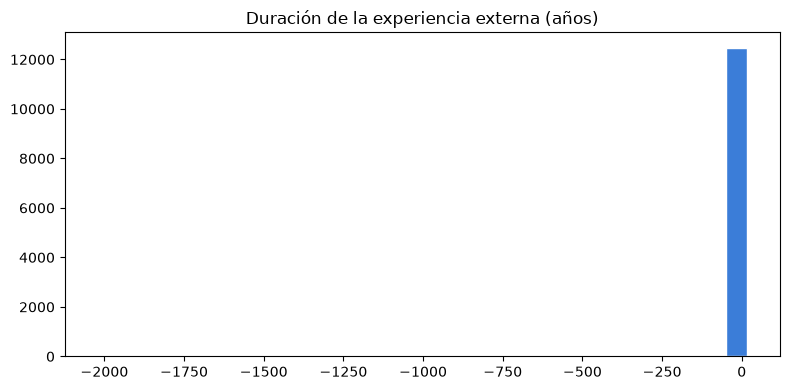

In [11]:
duracion_anios = (df['FECHAHASTA'] - df['FECHADESDE']).dt.days / 365.25
pc.grafico_histograma(duracion_anios, 'Duración de la experiencia externa (años)', bins=30)

**Países donde más experiencia externa se registra** (fuera de Ecuador incluido).

<Axes: title={'center': 'Top 10 países de experiencia externa'}, ylabel='PAIS'>

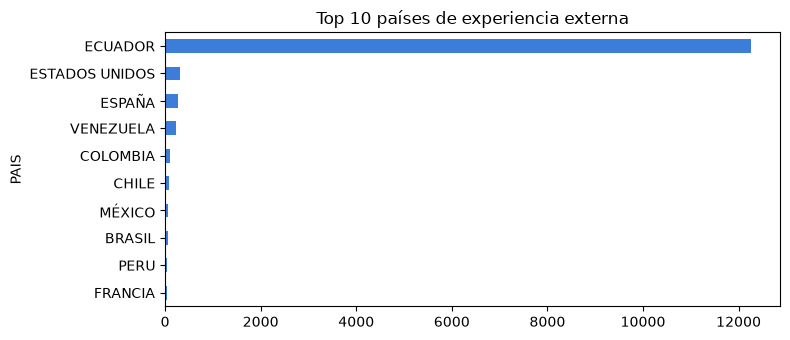

In [12]:
pc.grafico_barras(df['PAIS'], 'Top 10 países de experiencia externa', top=10)

## 7. Verificación final

In [13]:
pc.resumen(df, 'experiencia_externa (procesado)')
df.head()

--- Resumen experiencia_externa (procesado) ---
Dimensiones: 13818 filas x 20 columnas
Filas duplicadas: 0
Columnas con nulos (%):
REFEVALUACIONES            98.3
ROLACADEMICO_DESC          90.9
ROLACADEMICOEXPERIENCIA    90.9
ROLACADEMICO               90.9
REFEVIDENCIA               26.1
RELACIONLABORAL            20.6
CARGO                       9.4
FECHAHASTA                  8.8
TIPOINSTITUCION             4.7
INSTITUCION                 0.2
FECHADESDE                  0.1
dtype: float64


,IDHISTORIALABORAL,IDPERSONA,CARGO,INSTITUCION,TIPOINSTITUCION,RELACIONLABORAL,FECHADESDE,FECHAHASTA,PAIS,IDPAIS,TIEMPODEDICACION,REFEVIDENCIA,REFEVALUACIONES,CATEXPERIENCIA,CATEGORIAEXPERIENCIADESCRIPCION,ROLACADEMICO,ROLACADEMICOEXPERIENCIA,VIGENTE,CATEXPERIENCIA_DESC,ROLACADEMICO_DESC
0,8732,660654,AYUDANTE DE INVESTIGACIÓN,ESCUELA POLITÉCNICA NACIONAL,PÚBLICA,CONTRATO CON RELACIÓN DE DEPENDENCIA,2018-07-02,2019-08-31,ECUADOR,1,MEDIO TIEMPO,"456599,459052",<NA>,PC,POR CLASIFICAR,<NA>,<NA>,0,POR CLASIFICAR,NaN
1,87,1614,INGENIERA DE MANTENIMIENTO,FABRICACIONES ELECTROMECÁNICAS FETL S.A.,PRIVADA,CONTRATO SIN RELACIÓN DE DEPENDENCIA,1996-01-02,2000-11-30,ECUADOR,1,MEDIO TIEMPO,<NA>,<NA>,PC,POR CLASIFICAR,<NA>,<NA>,0,POR CLASIFICAR,NaN
2,11151,669877,ingeniero civil,celec,PÚBLICA,CONTRATO SIN RELACIÓN DE DEPENDENCIA,2018-08-03,2018-12-11,ECUADOR,1,MEDIO TIEMPO,"1012396,956161",<NA>,PC,POR CLASIFICAR,<NA>,<NA>,0,POR CLASIFICAR,NaN
3,295,1373,DOCENTE,UNIV. POLITECNICA SALESIANA,PRIVADA,CONTRATO CON RELACIÓN DE DEPENDENCIA,2008-06-01,2010-09-30,ECUADOR,1,MEDIO TIEMPO,"115174,114051",<NA>,PC,POR CLASIFICAR,<NA>,<NA>,0,POR CLASIFICAR,NaN
4,2903,1108,<NA>,UNIVERSIDAD POLITÉCNICA SALESIANA,<NA>,<NA>,2015-12-14,NaT,ECUADOR,1,MEDIO TIEMPO,"51882,50863","51883,50864",PC,POR CLASIFICAR,<NA>,<NA>,0,POR CLASIFICAR,NaN


## 8. Guardado en data/processed

In [14]:
pc.guardar_procesado(df, 'experiencia_externa.csv')

Guardado: D:\Proyecto_Tesis\data\processed\experiencia_externa.csv (13818 filas x 20 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/experiencia_externa.csv')